# 1. Imports

In [2]:
import pandas as pd                                                                                   # Manejar DataFrames
from pathlib import Path                                                                              # Manejar rutas
from sklearn.linear_model import LogisticRegression                                                   # Modelo Logistic
from sklearn.ensemble import RandomForestClassifier                                                   # Modelo RandomForest
from sklearn.tree import DecisionTreeClassifier                                                       # Modelo DecisionTree
from sklearn.neighbors import KNeighborsClassifier                                                    # Modelo K-nearest-neighbors
from sklearn.svm import SVC                                                                           # Modelo suport vector machine
from sklearn.pipeline import Pipeline                                                                 # Construir pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder                                       # Escalar valores/Convertir features categóricas en one-hot
from sklearn.impute import SimpleImputer                                                              # Imputar valores
from sklearn.compose import ColumnTransformer                                                         # Transformar columnas
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV   # Separar datos de entrenamiento y prueba/Folds/Validacion cruzada/Busqueda de hiperparámetros
import numpy as np                                                                                    # Operaciones matemáticas
import matplotlib.pyplot as plt                                                                       # Gráficos
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score    # Matrices de confusión/métrcias
import joblib
from sklearn.base import clone


# 2. Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic


In [4]:
MODEL_FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'models_figures'
print(MODEL_FIGURES_PATH)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic\outputs\models_figures


# 3. Import data

In [5]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'processed_data.csv')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    889 non-null    str    
 8   FamilySize  891 non-null    int64  
 9   IsAlone     891 non-null    int64  
 10  Title       891 non-null    str    
dtypes: float64(2), int64(7), str(2)
memory usage: 76.7 KB


# 4. Separate train/test data

Separaremos datos de entrenamiento y de prueba, en los datos de entrenamiento realizaremos pruebas de validación cruzada para evaluar estabilidad y rendimiento de los modelos

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
692,3,1,NaN,0,0,56.4958,S,1,1,Mr
481,2,1,NaN,0,0,0.0000,S,1,1,Mr
527,1,1,NaN,0,0,221.7792,S,1,1,Mr
855,3,0,18.0,0,1,9.3500,S,2,0,Mrs
801,2,0,31.0,1,1,26.2500,S,3,0,Mrs


# 5. Create Pipeline elements

Definimos las features que tienen que tener una transformación/imputación

In [10]:
numeric_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Embarked', 'Title']

Proceso (pipeline) para imputar los varoles numéricos, la idea es aplicar su mediana de los datos de entrenamiento y luego aplicar la misma mediana en el test

In [11]:
impute_median_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

Ahora con los datos no numéricos, en este caso es solo Embarked, que queremos que si faltan datos se impute con el valor más común, luego de eso queremos que se creen los datos OneHot

In [12]:
impute_mode_onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Creamos el objeto que va a transformar las columnas cuando ingrese el DataFrame. Que es como un pipeline, primero va a aplicar la lógica de imputar con mediana los valores numéricos y luego a los categoricos le va a aplicar el valor más común y luego one hot

In [13]:
preprocessor = ColumnTransformer([
    ('num', impute_median_pipeline, numeric_features),
    ('cat', impute_mode_onehot_pipeline, categorical_features)
])

# 6. StratifiedKfold

Ahora creamos el StratifiedKFold, lo que va a hacer es hacer pruebas con la misma cantidad de Survived en cada iteración, asegurando por ejemplo, que siempre sea un 80% que no sobrevivio y 20% que si lo hizo

In [14]:
cv = StratifiedKFold(
    n_splits=5,         # 5 iteraciones, por ende, 5 folds
    shuffle=True,       # Revolver los datos antes de probar (así si es que el dataframe viene con todos los pclass 1 primero por ejemplo, se revuelva)
    random_state=42     # Semilla de como seleccionar los datos
)

# 7. Test default models

Ahora vamos a probar como se comportan y qué metricas obtienen cada uno de nuestros modelos. Primero los instanciaremos todos.

In [15]:
logistic = LogisticRegression()
decision_tree = DecisionTreeClassifier()
random_forest = RandomForestClassifier()
knn = KNeighborsClassifier()
svc = SVC()

Constante para pintar gráficos

In [16]:
SURVIVED_COLORS = ["#ff4343", "#3a68fd"]

In [17]:
METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']      # Métricas que queremos evaluar

## 7.1 Logistic Regression

### 7.1.1 Pipeline

Creamos Pipeline para Logistic Regression, al ingresar los datos, se transforman/imputan, luego se escalan y finalmente el modelo hace la estimación

In [18]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),     # Preprocesar las columnas, imputación de numéricos con mediana / imputación de categóricos con moda y onehot
    ('scaler', StandardScaler()),       # Escalar los datos
    ('model', logistic)               # Modelo a utilizar luego de todo eso
])

### 7.1.2 Cross validate

Aquí es donde vemos como se comporta el modelo para distintas situaciones y distintas porciones de datos

In [19]:
results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [20]:
results

{'fit_time': array([0.0501399 , 0.01990104, 0.01845908, 0.0177474 , 0.01844883]),
 'score_time': array([0.02928758, 0.02864003, 0.0256834 , 0.02422643, 0.02412295]),
 'test_accuracy': array([0.82517483, 0.81118881, 0.85211268, 0.79577465, 0.84507042]),
 'test_precision': array([0.77777778, 0.79166667, 0.84      , 0.71186441, 0.83333333]),
 'test_recall': array([0.76363636, 0.69090909, 0.76363636, 0.77777778, 0.74074074]),
 'test_f1': array([0.7706422 , 0.73786408, 0.8       , 0.74336283, 0.78431373]),
 'test_roc_auc': array([0.86084711, 0.85444215, 0.9014629 , 0.84185606, 0.87657828])}

### 7.1.3 Visualization

Obtenemos los promedios de cada métrica

In [21]:
mean_accuracy_logistic_folds = np.mean(results['test_accuracy'])
mean_precision_logistic_folds = np.mean(results['test_precision'])
mean_recall_logistic_folds = np.mean(results['test_recall'])
mean_f1_logistic_folds = np.mean(results['test_f1'])
mean_roc_auc_logistic_folds = np.mean(results['test_roc_auc'])

Obtenemos distribución estandar de para ver variabilidad de los folds

In [22]:
std_accuracy_logistic_folds = np.std(results['test_accuracy'])
std_precision_logistic_folds = np.std(results['test_precision'])
std_recall_logistic_folds = np.std(results['test_recall'])
std_f1_logistic_folds = np.std(results['test_f1'])
std_roc_auc_logistic_folds = np.std(results['test_roc_auc'])

Guardar resultados en listas

In [23]:
means_logistic_folds = [
    mean_accuracy_logistic_folds,
    mean_precision_logistic_folds,
    mean_recall_logistic_folds,
    mean_f1_logistic_folds,
    mean_roc_auc_logistic_folds
]

stds_logistic_folds = [
    std_accuracy_logistic_folds,
    std_precision_logistic_folds,
    std_recall_logistic_folds,
    std_f1_logistic_folds,
    std_roc_auc_logistic_folds
]

Visualizar

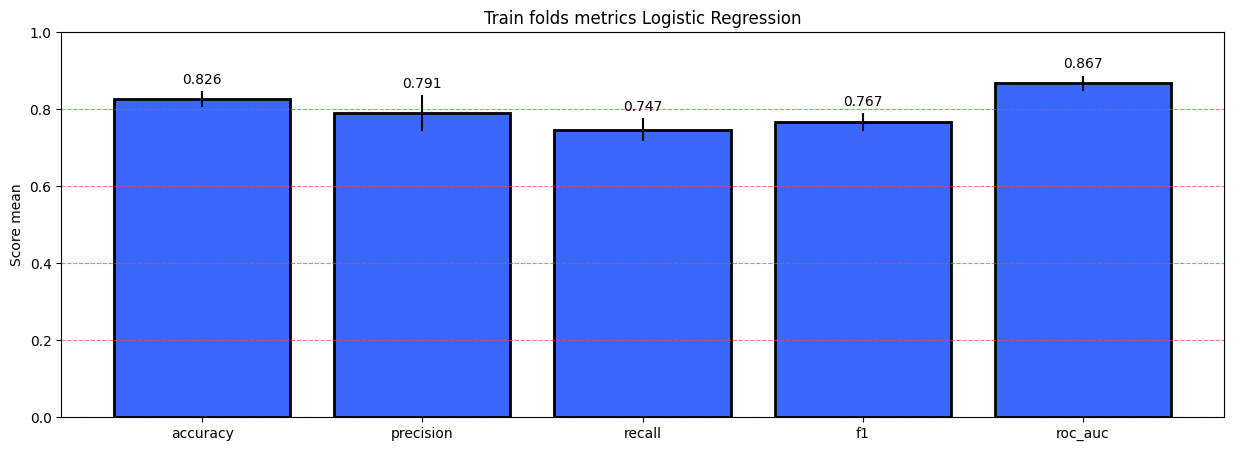

In [24]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,            # Poner de partida 5 barras
    means_logistic_folds,             # La altura de cada barra está dada por el valor de cada métrica
    yerr=stds_logistic_folds,         # Mostrar lo que puede variar cada barra
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])

ax.set_ylabel('Score mean')

ax.set_title('Train folds metrics Logistic Regression')

plt.savefig(MODEL_FIGURES_PATH / '01_train_metrics_logistic_regression.png', bbox_inches='tight')
plt.show()

### 7.1.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [25]:
logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

Matriz de confusión

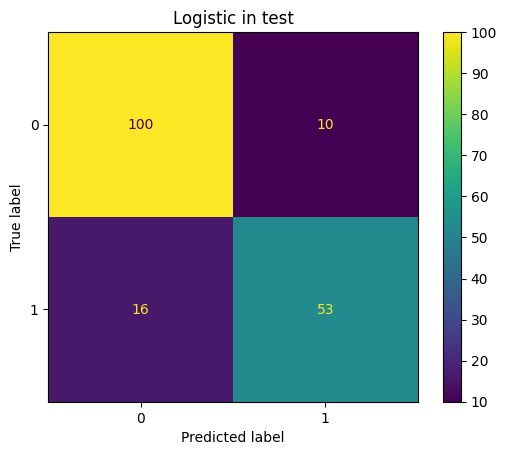

In [26]:
confusion_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)

display_confusion_matrix_logistic = ConfusionMatrixDisplay(confusion_matrix_logistic)

display_confusion_matrix_logistic.plot()

plt.title('Logistic in test')

plt.savefig(MODEL_FIGURES_PATH / '01_01_confusion_matrix_logistic')
plt.show()

## 7.2 Random Forest Classifier 1

### 7.2.1 Pipeline

In [27]:
random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', random_forest)
])

### 7.2.2 Cross validate

In [28]:
results_random_forest_folds = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [29]:
results_random_forest_folds

{'fit_time': array([0.2067349 , 0.19688797, 0.20020938, 0.1904645 , 0.25962663]),
 'score_time': array([0.04559088, 0.04667044, 0.04655266, 0.04485393, 0.04812837]),
 'test_accuracy': array([0.81118881, 0.79020979, 0.78873239, 0.82394366, 0.81690141]),
 'test_precision': array([0.75      , 0.72727273, 0.74509804, 0.76363636, 0.80434783]),
 'test_recall': array([0.76363636, 0.72727273, 0.69090909, 0.77777778, 0.68518519]),
 'test_f1': array([0.75675676, 0.72727273, 0.71698113, 0.7706422 , 0.74      ]),
 'test_roc_auc': array([0.85227273, 0.85020661, 0.88996865, 0.8844697 , 0.86805556])}

In [30]:
mean_accuracy_random_forest_folds = np.mean(results_random_forest_folds['test_accuracy'])
mean_precision_random_forest_folds = np.mean(results_random_forest_folds['test_precision'])
mean_recall_random_forest_folds = np.mean(results_random_forest_folds['test_recall'])
mean_f1_random_forest_folds = np.mean(results_random_forest_folds['test_f1'])
mean_roc_auc_random_forest_folds = np.mean(results_random_forest_folds['test_roc_auc'])

In [31]:
std_accuracy_random_forest_folds = np.std(results_random_forest_folds['test_accuracy'])
std_precision_random_forest_folds = np.std(results_random_forest_folds['test_precision'])
std_recall_random_forest_folds = np.std(results_random_forest_folds['test_recall'])
std_f1_random_forest_folds = np.std(results_random_forest_folds['test_f1'])
std_roc_auc_random_forest_folds = np.std(results_random_forest_folds['test_roc_auc'])

In [32]:
means_random_forest_folds = [
    mean_accuracy_random_forest_folds,
    mean_precision_random_forest_folds,
    mean_recall_random_forest_folds,
    mean_f1_random_forest_folds,
    mean_roc_auc_random_forest_folds
]

In [33]:
stds_random_forest_fols = [
    std_accuracy_random_forest_folds,
    std_precision_random_forest_folds,
    std_recall_random_forest_folds,
    std_f1_random_forest_folds,
    std_roc_auc_random_forest_folds
]

### 7.2.3 Visualization

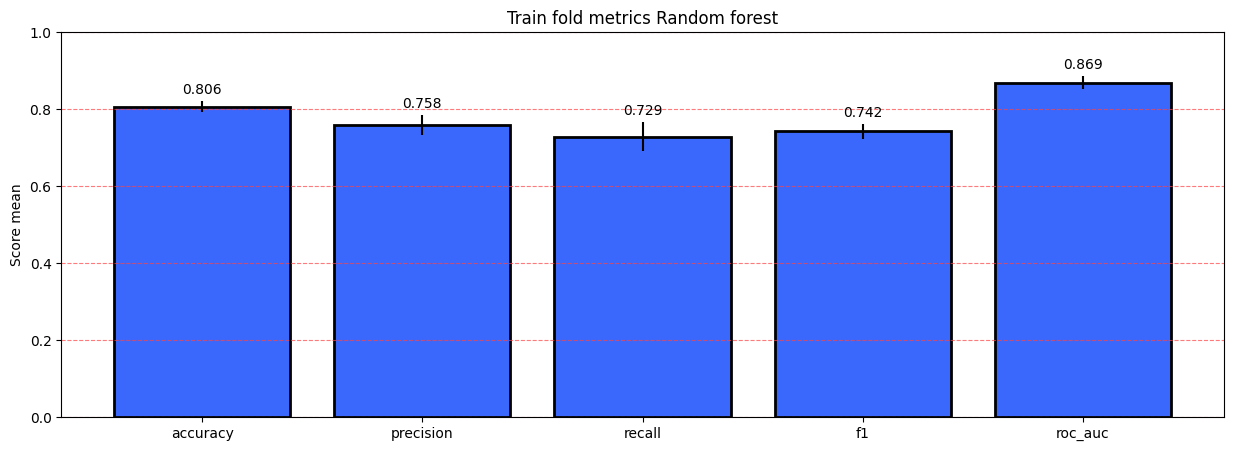

In [34]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_random_forest_folds,
    yerr=stds_random_forest_fols,
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics Random forest')


plt.savefig(MODEL_FIGURES_PATH / '02_train_metrics_random_forest', bbox_inches='tight')
plt.show()

### 7.2.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [35]:
random_forest_pipeline.fit(X_train, y_train)

y_pred_random_forest = random_forest_pipeline.predict(X_test)

Matriz de confusión

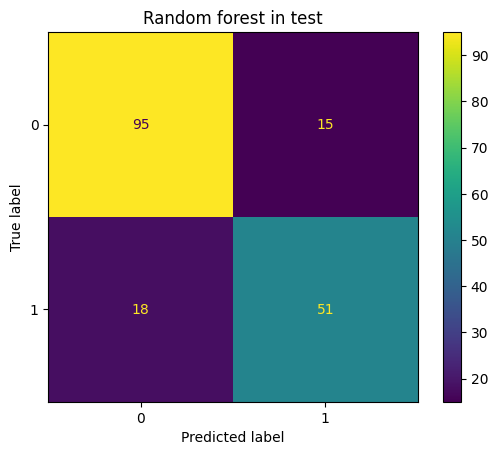

In [36]:
confusion_matrix_random_forest = confusion_matrix(y_test, y_pred_random_forest)

display_confusion_matrix_random_forest = ConfusionMatrixDisplay(confusion_matrix_random_forest)

display_confusion_matrix_random_forest.plot()

plt.title('Random forest in test')

plt.savefig(MODEL_FIGURES_PATH / '02_01_confusion_matrix_random_forest')
plt.show()

## 7.3 Decision Tree Classifier 1

### 7.3.1 Pipeline

In [37]:
decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', decision_tree)
])

### 7.3.2 Cross validate

In [38]:
results_decision_tree_folds = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [39]:
results_decision_tree_folds

{'fit_time': array([0.02367544, 0.03042698, 0.04102898, 0.02385354, 0.03003645]),
 'score_time': array([0.0476799 , 0.04796386, 0.04627681, 0.04093671, 0.0390842 ]),
 'test_accuracy': array([0.76923077, 0.77622378, 0.78169014, 0.77464789, 0.78169014]),
 'test_precision': array([0.68333333, 0.70909091, 0.72222222, 0.69642857, 0.7254902 ]),
 'test_recall': array([0.74545455, 0.70909091, 0.70909091, 0.72222222, 0.68518519]),
 'test_f1': array([0.71304348, 0.70909091, 0.71559633, 0.70909091, 0.7047619 ]),
 'test_roc_auc': array([0.76714876, 0.76642562, 0.76760711, 0.76557239, 0.75652357])}

In [40]:
mean_accuracy_decision_tree_folds = np.mean(results_decision_tree_folds['test_accuracy'])
mean_precision_decision_tree_folds = np.mean(results_decision_tree_folds['test_precision'])
mean_recall_decision_tree_folds = np.mean(results_decision_tree_folds['test_recall'])
mean_f1_decision_tree_folds = np.mean(results_decision_tree_folds['test_f1'])
mean_roc_auc_decision_tree_folds = np.mean(results_decision_tree_folds['test_roc_auc'])

In [41]:
std_accuracy_decision_tree_folds = np.std(results_decision_tree_folds['test_accuracy'])
std_precision_decision_tree_folds = np.std(results_decision_tree_folds['test_precision'])
std_recall_decision_tree_folds = np.std(results_decision_tree_folds['test_recall'])
std_f1_decision_tree_folds = np.std(results_decision_tree_folds['test_f1'])
std_roc_auc_decision_tree_folds = np.std(results_decision_tree_folds['test_roc_auc'])

In [42]:
means_decision_tree_folds = [
    mean_accuracy_decision_tree_folds,
    mean_precision_decision_tree_folds,
    mean_recall_decision_tree_folds,
    mean_f1_decision_tree_folds,
    mean_roc_auc_decision_tree_folds
]

In [43]:
stds_decision_tree_fols = [
    std_accuracy_decision_tree_folds,
    std_precision_decision_tree_folds,
    std_recall_decision_tree_folds,
    std_f1_decision_tree_folds,
    std_roc_auc_decision_tree_folds
]

### 7.3.3 Visualization

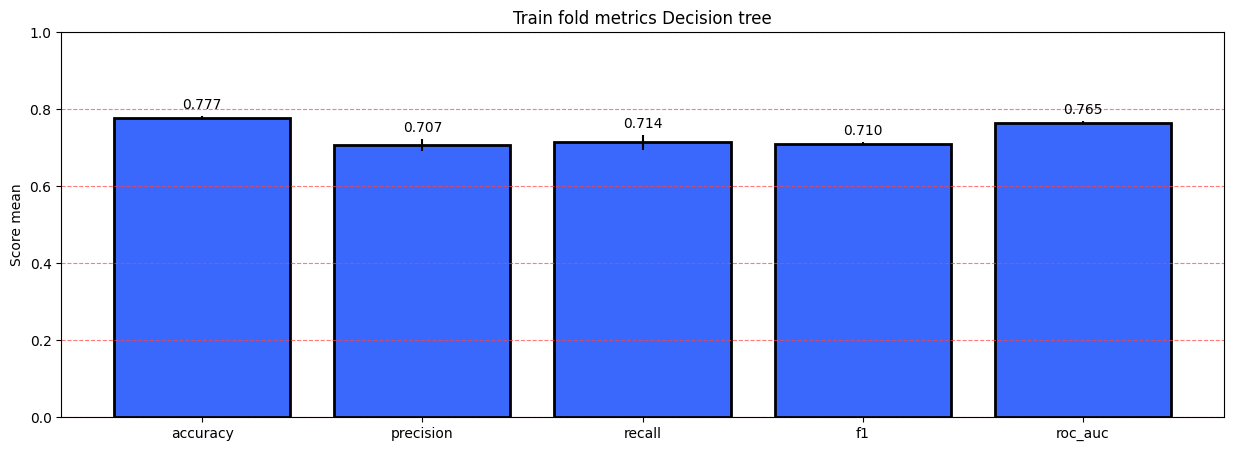

In [44]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_decision_tree_folds,
    yerr=stds_decision_tree_fols,
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics Decision tree')


plt.savefig(MODEL_FIGURES_PATH / '03_train_metrics_decision_tree', bbox_inches='tight')
plt.show()

### 7.3.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [45]:
decision_tree_pipeline.fit(X_train, y_train)

y_pred_decision_tree = decision_tree_pipeline.predict(X_test)

Matriz de confusión

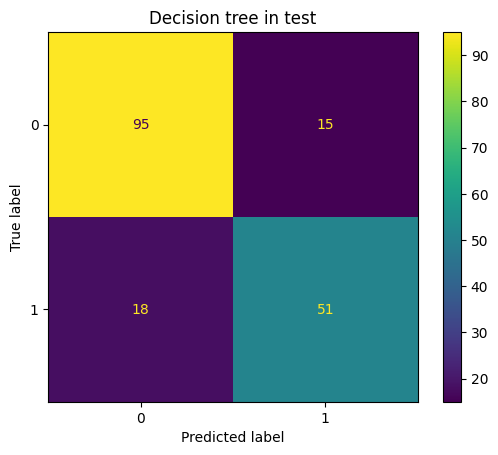

In [46]:
confusion_matrix_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)

display_confusion_matrix_decision_tree = ConfusionMatrixDisplay(confusion_matrix_decision_tree)

display_confusion_matrix_decision_tree.plot()

plt.title('Decision tree in test')

plt.savefig(MODEL_FIGURES_PATH / '03_01_confusion_matrix_decision_tree')
plt.show()

## 7.4 KNN Classifier 1

### 7.4.1 Pipeline

In [47]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', knn)
])

### 7.4.2 Cross validate

In [48]:
results_knn_folds = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [49]:
results_knn_folds

{'fit_time': array([0.02440596, 0.03631997, 0.03366065, 0.03317285, 0.03194547]),
 'score_time': array([0.41316795, 0.12018347, 0.09983039, 0.11237264, 0.09498954]),
 'test_accuracy': array([0.8041958 , 0.79020979, 0.84507042, 0.82394366, 0.80985915]),
 'test_precision': array([0.75471698, 0.76595745, 0.85106383, 0.78431373, 0.81395349]),
 'test_recall': array([0.72727273, 0.65454545, 0.72727273, 0.74074074, 0.64814815]),
 'test_f1': array([0.74074074, 0.70588235, 0.78431373, 0.76190476, 0.72164948]),
 'test_roc_auc': array([0.83202479, 0.83429752, 0.89780564, 0.86363636, 0.82680976])}

In [50]:
mean_accuracy_knn_folds = np.mean(results_knn_folds['test_accuracy'])
mean_precision_knn_folds = np.mean(results_knn_folds['test_precision'])
mean_recall_knn_folds = np.mean(results_knn_folds['test_recall'])
mean_f1_knn_folds = np.mean(results_knn_folds['test_f1'])
mean_roc_auc_knn_folds = np.mean(results_knn_folds['test_roc_auc'])

In [51]:
std_accuracy_knn_folds = np.std(results_knn_folds['test_accuracy'])
std_precision_knn_folds = np.std(results_knn_folds['test_precision'])
std_recall_knn_folds = np.std(results_knn_folds['test_recall'])
std_f1_knn_folds = np.std(results_knn_folds['test_f1'])
std_roc_auc_knn_folds = np.std(results_knn_folds['test_roc_auc'])

In [52]:
means_knn_folds = [
    mean_accuracy_knn_folds,
    mean_precision_knn_folds,
    mean_recall_knn_folds,
    mean_f1_knn_folds,
    mean_roc_auc_knn_folds
]

In [53]:
stds_knn_fols = [
    std_accuracy_knn_folds,
    std_precision_knn_folds,
    std_recall_knn_folds,
    std_f1_knn_folds,
    std_roc_auc_knn_folds
]

### 7.4.3 Visualization

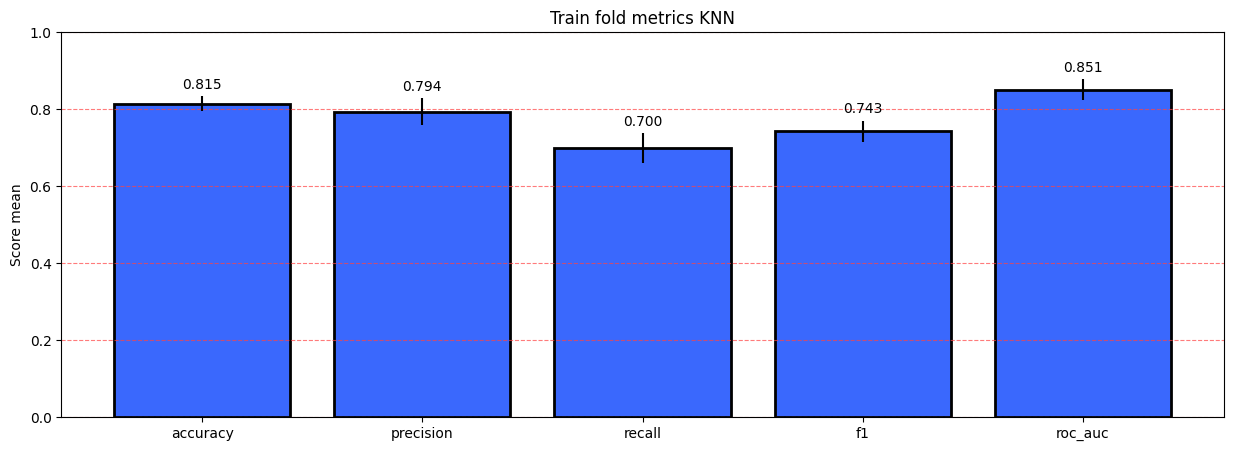

In [54]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_knn_folds,
    yerr=stds_knn_fols,
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics KNN')


plt.savefig(MODEL_FIGURES_PATH / '04_train_metrics_knn', bbox_inches='tight')
plt.show()

### 7.4.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [55]:
knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

Matriz de confusión

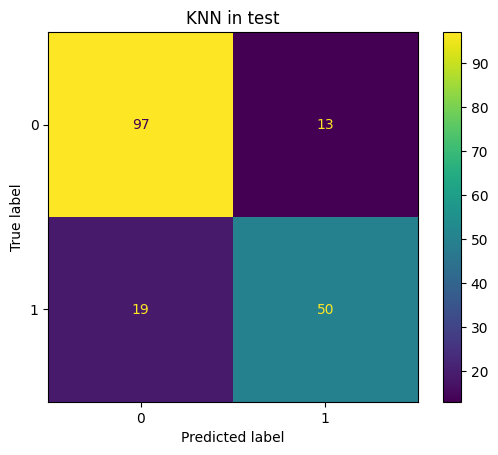

In [56]:
confusion_matrix_knn = confusion_matrix(y_test, y_pred_knn)

display_confusion_matrix_knn = ConfusionMatrixDisplay(confusion_matrix_knn)

display_confusion_matrix_knn.plot()

plt.title('KNN in test')

plt.savefig(MODEL_FIGURES_PATH / '04_01_confusion_matrix_knn')
plt.show()

## 7.5 SVC 1

### 7.4.1 Pipeline

In [57]:
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', svc)
])

### 7.4.2 Cross validate

In [58]:
results_svc_folds = cross_validate(
    svc_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [59]:
results_svc_folds

{'fit_time': array([0.13506198, 0.07945943, 0.05067778, 0.07395315, 0.04852796]),
 'score_time': array([0.09655929, 0.10361838, 0.075948  , 0.10327864, 0.04929638]),
 'test_accuracy': array([0.83216783, 0.8041958 , 0.86619718, 0.8028169 , 0.80985915]),
 'test_precision': array([0.80392157, 0.8       , 0.875     , 0.75      , 0.82926829]),
 'test_recall': array([0.74545455, 0.65454545, 0.76363636, 0.72222222, 0.62962963]),
 'test_f1': array([0.77358491, 0.72      , 0.81553398, 0.73584906, 0.71578947]),
 'test_roc_auc': array([0.85423554, 0.81126033, 0.91003135, 0.83638468, 0.83491162])}

In [60]:
mean_accuracy_svc_folds = np.mean(results_svc_folds['test_accuracy'])
mean_precision_svc_folds = np.mean(results_svc_folds['test_precision'])
mean_recall_svc_folds = np.mean(results_svc_folds['test_recall'])
mean_f1_svc_folds = np.mean(results_svc_folds['test_f1'])
mean_roc_auc_svc_folds = np.mean(results_svc_folds['test_roc_auc'])

In [61]:
std_accuracy_svc_folds = np.std(results_svc_folds['test_accuracy'])
std_precision_svc_folds = np.std(results_svc_folds['test_precision'])
std_recall_svc_folds = np.std(results_svc_folds['test_recall'])
std_f1_svc_folds = np.std(results_svc_folds['test_f1'])
std_roc_auc_svc_folds = np.std(results_svc_folds['test_roc_auc'])

In [62]:
means_svc_folds = [
    mean_accuracy_svc_folds,
    mean_precision_svc_folds,
    mean_recall_svc_folds,
    mean_f1_svc_folds,
    mean_roc_auc_svc_folds
]

In [63]:
stds_svc_fols = [
    std_accuracy_svc_folds,
    std_precision_svc_folds,
    std_recall_svc_folds,
    std_f1_svc_folds,
    std_roc_auc_svc_folds
]

### 7.4.3 Visualization

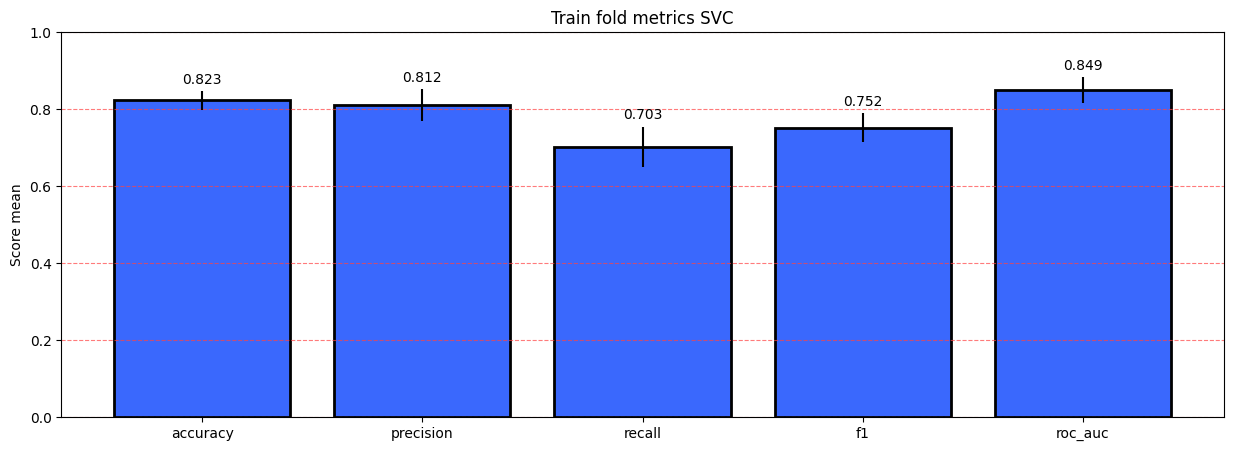

In [64]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_svc_folds,
    yerr=stds_svc_fols,
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics SVC')


plt.savefig(MODEL_FIGURES_PATH / '05_train_metrics_svc', bbox_inches='tight')
plt.show()

### 7.4.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [65]:
svc_pipeline.fit(X_train, y_train)

y_pred_svc = svc_pipeline.predict(X_test)

Matriz de confusión

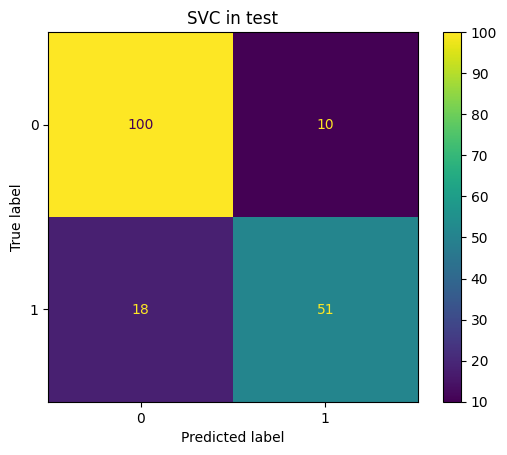

In [66]:
confusion_matrix_svc = confusion_matrix(y_test, y_pred_svc)

display_confusion_matrix_svc = ConfusionMatrixDisplay(confusion_matrix_svc)

display_confusion_matrix_svc.plot()

plt.title('SVC in test')

plt.savefig(MODEL_FIGURES_PATH / '05_01_confusion_matrix_svc')
plt.show()

# 8. GridSearchCV

Haremos este proceso solo para LogisticRegression y RandomForestClassifier, ya que fueron los que mejores métricas obtuvieron

## 8.1 Grids

Param grid para modelo LogisticRegression

In [67]:
param_grid_logistic_regression = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, "balanced"]
}

Param grid para modelo RandomForestClassifier

In [68]:
param_grid_random_forest = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 3, 4, 5],
    'model__class_weight': [None, 'balanced']
}

## 8.2 Instantiate CV's

LogisticRegression

In [69]:
grid_search_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_logistic_regression,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

RandomForestClassifier

In [70]:
grid_search_random_forest = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_random_forest,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

## 8.3 Test models

### 8.3.1 LogisticRegresion

#### 8.3.1.1 Fit and predict

In [71]:
grid_search_logistic.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [72]:
y_pred_logistic_gridsearch = grid_search_logistic.predict(X_test)

#### 8.3.1.2 Metrics

In [73]:
accuracy_gridsearch_logistic = accuracy_score(y_test, y_pred_logistic_gridsearch)
precision_gridsearch_logistic = precision_score(y_test, y_pred_logistic_gridsearch)
recall_gridsearch_logistic = recall_score(y_test, y_pred_logistic_gridsearch)
f1_gridsearch_logistic = f1_score(y_test, y_pred_logistic_gridsearch)
roc_auc_gridsearch_logistic = roc_auc_score(y_test, y_pred_logistic_gridsearch)

In [74]:
metrics_logistic_gridsearch = [
    accuracy_gridsearch_logistic,
    precision_gridsearch_logistic,
    recall_gridsearch_logistic,
    f1_gridsearch_logistic,
    roc_auc_gridsearch_logistic
]

In [75]:
confusion_matrix_gridsearch_logistic = confusion_matrix(y_test, y_pred_logistic_gridsearch)
confusion_matrix_gridsearch_logistic_display = ConfusionMatrixDisplay(confusion_matrix_gridsearch_logistic)

#### 8.3.1.3 Visualize

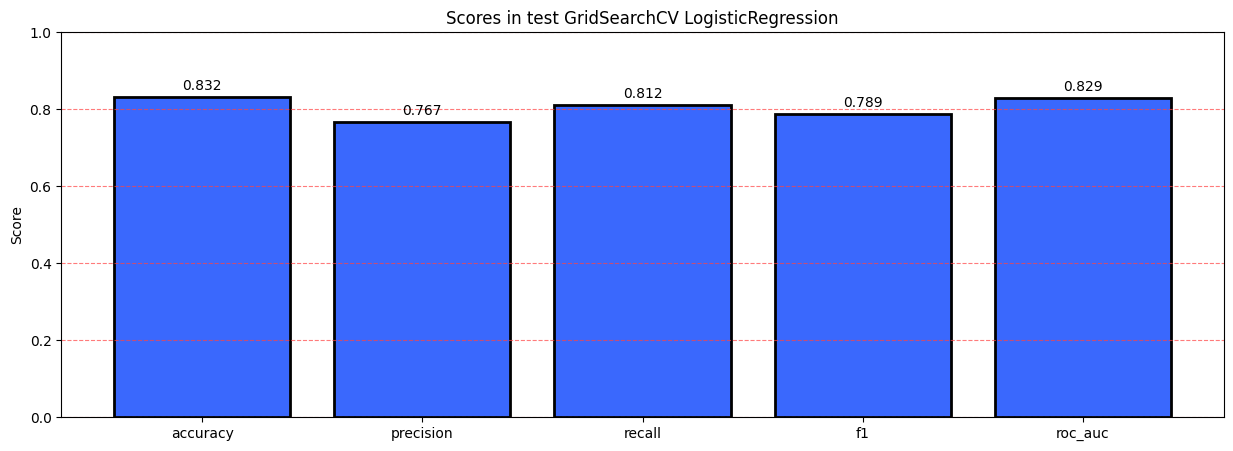

In [76]:
fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    METRICS,
    height=metrics_logistic_gridsearch,
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

plt.ylim([0, 1])

plt.ylabel('Score')
plt.title('Scores in test GridSearchCV LogisticRegression')

plt.savefig(MODEL_FIGURES_PATH / '06_test_metrics_logistic_gridsearch.png', bbox_inches='tight')
plt.show()

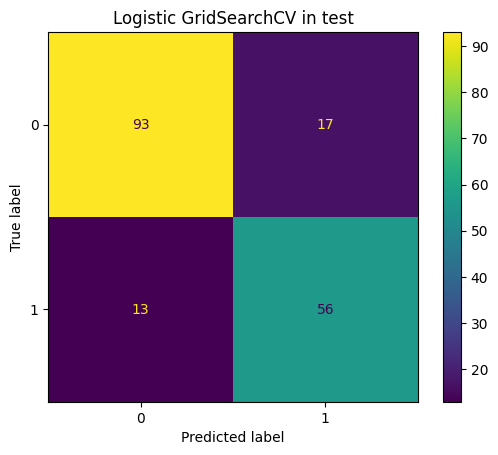

In [77]:
confusion_matrix_gridsearch_logistic_display.plot()

plt.title('Logistic GridSearchCV in test')

plt.savefig(MODEL_FIGURES_PATH / '06_01_confusion_matrix_logistic_gridsearch.png')
plt.show()

### 8.3.2 RandomForestClassifier

#### 8.3.2.1 Fit and predict

In [78]:
grid_search_random_forest.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the 

In [79]:
y_pred_random_forest_gridsearch = grid_search_random_forest.predict(X_test)

#### 8.3.2.2 Metrics

In [80]:
accuracy_gridsearch_random_forest = accuracy_score(y_test, y_pred_random_forest_gridsearch)
precision_gridsearch_random_forest = precision_score(y_test, y_pred_random_forest_gridsearch)
recall_gridsearch_random_forest = recall_score(y_test, y_pred_random_forest_gridsearch)
f1_gridsearch_random_forest = f1_score(y_test, y_pred_random_forest_gridsearch)
roc_auc_gridsearch_random_forest = roc_auc_score(y_test, y_pred_random_forest_gridsearch)

In [81]:
metrics_random_forest_gridsearch = [
    accuracy_gridsearch_random_forest,
    precision_gridsearch_random_forest,
    recall_gridsearch_random_forest,
    f1_gridsearch_random_forest,
    roc_auc_gridsearch_random_forest
]

In [82]:
confusion_matrix_gridsearch_random_forest = confusion_matrix(y_test, y_pred_random_forest_gridsearch)
confusion_matrix_gridsearch_random_forest_display = ConfusionMatrixDisplay(confusion_matrix_gridsearch_random_forest)

#### 8.3.1.3 Visualize

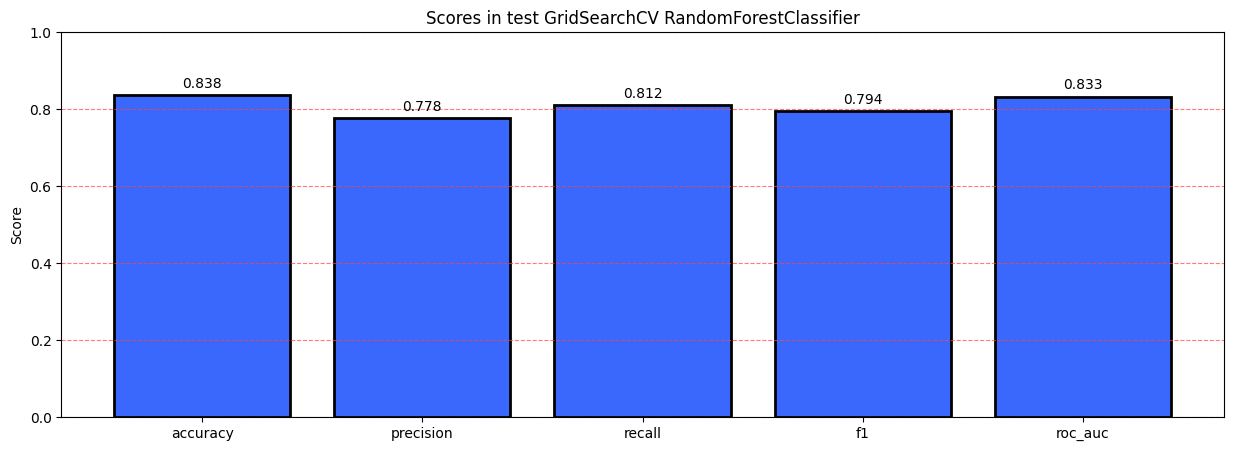

In [83]:
fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    METRICS,
    height=metrics_random_forest_gridsearch,
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

ax.bar_label(bars, fmt='%.3f', padding=3)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

plt.ylim([0, 1])

plt.ylabel('Score')
plt.title('Scores in test GridSearchCV RandomForestClassifier')

plt.savefig(MODEL_FIGURES_PATH / '07_test_metrics_random_forest_gridsearch.png', bbox_inches='tight')
plt.show()

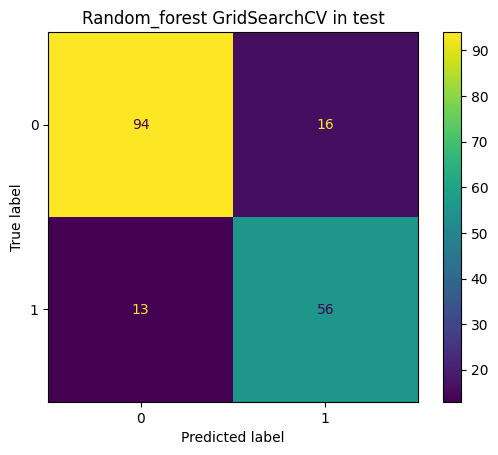

In [84]:
confusion_matrix_gridsearch_random_forest_display.plot()

plt.title('Random_forest GridSearchCV in test')

plt.savefig(MODEL_FIGURES_PATH / '07_01_confusion_matrix_random_forest_gridsearch.png')
plt.show()

## 8.4 Best params and scores

LogisticRegression

In [85]:
print(f'Best params LogisticRegression: {grid_search_logistic.best_params_}')
print(f'Best score LogisticRegression: {grid_search_logistic.best_score_}')

Best params LogisticRegression: {'model__C': 1, 'model__class_weight': 'balanced'}
Best score LogisticRegression: 0.7913131313131314


RandomForestClassifier

In [86]:
print(f'Best params RandomForestClassifier: {grid_search_random_forest.best_params_}')
print(f'Best score RandomForestClassifier: {grid_search_random_forest.best_score_}')

Best params RandomForestClassifier: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
Best score RandomForestClassifier: 0.7763636363636364


# 9. Save models

## 9.1 Train best estimator

Ahora vamos a entrenar el modelo con los mejores hiperparámetros y pasandole el dataset completo

In [87]:
final_model = clone(grid_search_random_forest.best_estimator_)

In [88]:
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

## 9.2 Save model

In [89]:
joblib.dump(final_model, PROJECT_ROOT / 'models' / 'random_forest_model.pkl')

['c:\\Users\\Carlos\\Documents\\Ingenieria_informatica\\Proyectos_datascience\\2_titanic\\models\\random_forest_model.pkl']